In [ ]:
!pip install tensorflow pandas matplotlib scikit-learn requests -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import requests

print("Ready")

Ready


In [ ]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 29.76,
    "longitude": -95.37,
    "start_date": "2022-02-01",
    "end_date": "2025-02-04",
    "daily": "temperature_2m_mean",
    "temperature_unit": "fahrenheit"
}

response = requests.get(url, params=params)
data = response.json()

temperatures = np.array(data['daily']['temperature_2m_mean'])
dates = pd.to_datetime(data['daily']['time'])

print(f"Downloaded {len(temperatures)} days for data!")
print(f"Range: {temperatures.min():.1f}F to {temperatures.max():.1f}F")

Downloaded 1100 days for data!
Range: 23.4F to 92.0F


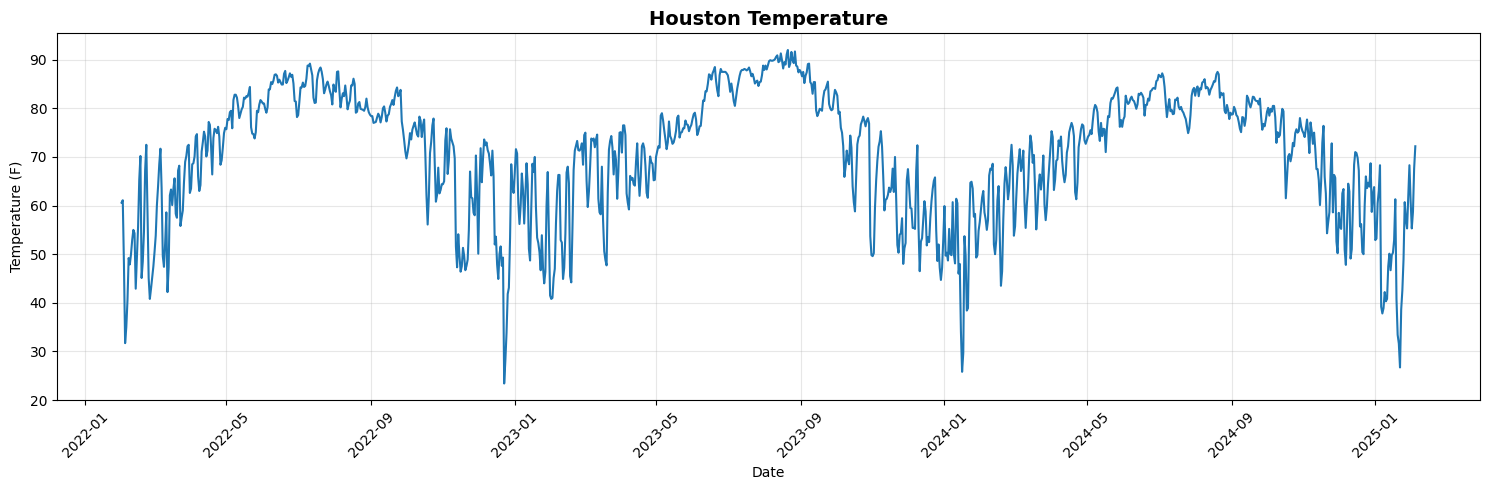

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(dates, temperatures)
plt.title('Houston Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Temperature (F)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
scaler = MinMaxScaler()
temps_scaled = scaler.fit_transform(temperatures.reshape(-1, 1))
X, y = [], []
for i in range(30, len(temps_scaled)):
  X.append(temps_scaled[i-30:i])
  y.append(temps_scaled[i])

X = np.array(X)
y = np.array(y)

print(f"Created {len(X)} training examples")
print(f"Each example: use 30 days --> predict day 31")

Created 1070 training examples
Each example: use 30 days --> predict day 31


In [ ]:
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]
X_test = X[split:]
y_test = y[split:]

test_dates = dates[split + 30:]

print(f"Training: {len(X_train)} examples")
print(f"Testing: {len(X_test)} examples")
print("\nWhy test? To see if the model works on data it has never seen!")

Training: 856 examples
Testing: 214 examples

Why test? To see if the model works on data it has never seen!


In [ ]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(30, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Model Created!")
model.summary()

Model Created!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=12,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.2387 - mae: 0.4243 - val_loss: 0.0074 - val_mae: 0.0626
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0092 - mae: 0.0711 - val_loss: 0.0077 - val_mae: 0.0677
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0072 - mae: 0.0635 - val_loss: 0.0081 - val_mae: 0.0721
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0089 - mae: 0.0699 - val_loss: 0.0079 - val_mae: 0.0708
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0082 - mae: 0.0678 - val_loss: 0.0075 - val_mae: 0.0677
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0081 - mae: 0.0667 - val_loss: 0.0083 - val_mae: 0.0752
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0081 - mae: 0.0662 - val_loss: 0.0083 - val_mae: 0.0752
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0081 - mae: 0.0677 - val_loss: 0.0069 - val_mae: 0.0602
Epoch 9/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.008

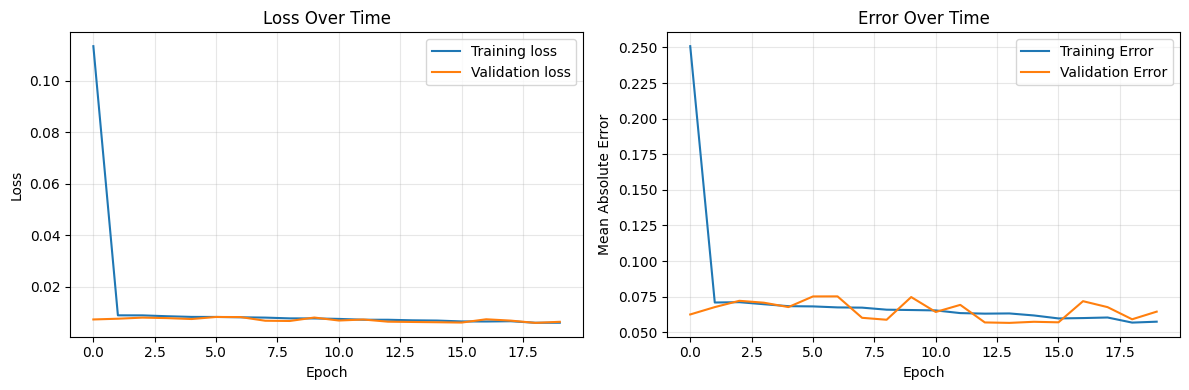

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training Error')
plt.plot(history.history['val_mae'], label='Validation Error')
plt.title('Error Over Time')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
predictions_scaled = model.predict(X_test, verbose=0)

predictions = scaler.inverse_transform(predictions_scaled)
actual = scaler.inverse_transform(y_test)

error = np.mean(np.abs(predictions - actual))

print(f"Average error: {error:.2f}F")
print(f"\nWhat this means: On average, predictions are off by +-{error:.1f}F")

Average error: 3.83F

What this means: On average, predictions are off by +-3.8F


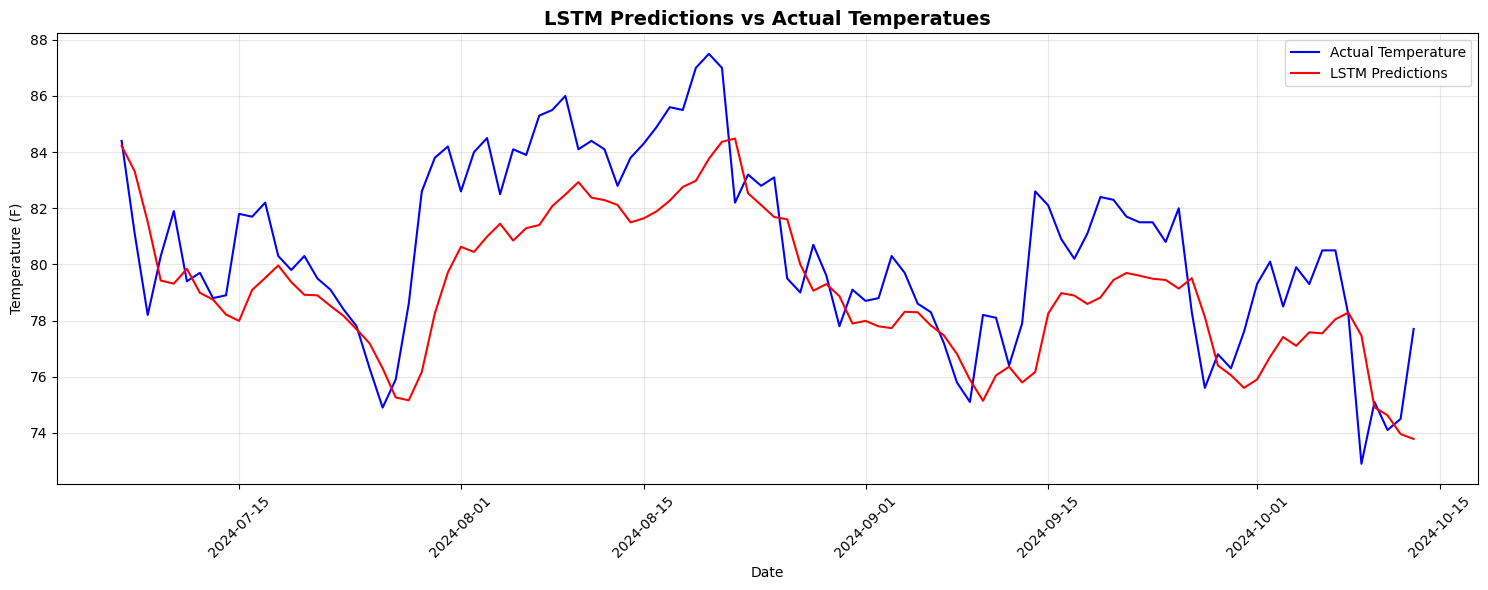

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(test_dates[:100], actual[:100], label='Actual Temperature', color='blue')
plt.plot(test_dates[:100], predictions[:100], label='LSTM Predictions', color='red')

plt.title('LSTM Predictions vs Actual Temperatues', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Temperature (F)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()